In [2]:
import sys
sys.path.insert(0, "/content/xlstm")

import xlstm
print(xlstm.__file__)

/content/xlstm/xlstm/__init__.py


In [3]:
from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    mLSTMBlockConfig,
    mLSTMLayerConfig,
    sLSTMBlockConfig,
    sLSTMLayerConfig,
)

print("xLSTM works")

xLSTM works


In [4]:
%cd /content

/content


In [5]:
!ls dataProcessed

In [6]:
%cd /content/ecg5000-timeseries-project/projects/ecg5000 
!ls dataProcessed

/content/ecg5000-timeseries-project/projects/ecg5000
ECG5000_CV_4000.txt	       ECG5000_FOLD_3_TRAIN_3200.txt
ECG5000_FINAL_TEST_1000.txt    ECG5000_FOLD_3_VAL_800.txt
ECG5000_FOLD_1_800.txt	       ECG5000_FOLD_4_800.txt
ECG5000_FOLD_1_TRAIN_3200.txt  ECG5000_FOLD_4_TRAIN_3200.txt
ECG5000_FOLD_1_VAL_800.txt     ECG5000_FOLD_4_VAL_800.txt
ECG5000_FOLD_2_800.txt	       ECG5000_FOLD_5_800.txt
ECG5000_FOLD_2_TRAIN_3200.txt  ECG5000_FOLD_5_TRAIN_3200.txt
ECG5000_FOLD_2_VAL_800.txt     ECG5000_FOLD_5_VAL_800.txt
ECG5000_FOLD_3_800.txt


True
Cuda version: 12.8


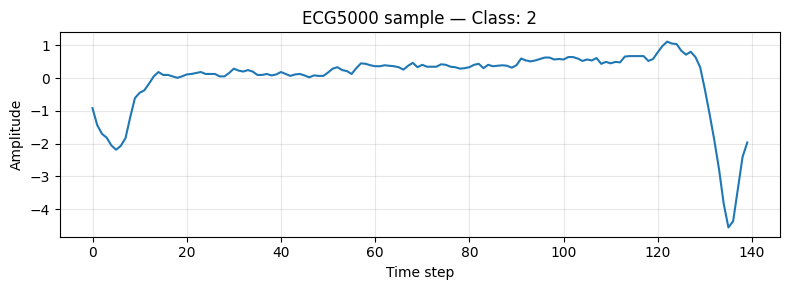

Train shape: (3200, 140, 1)
Val shape: (800, 140, 1)
Test shape: (1000, 140, 1)
Classes: ['1' '2' '3' '4' '5']
Model has 78533 trainable parameters.
Epoch:   1 | Train loss: 0.34249424| Val loss: 0.21050341 | Best Val loss: 0.21050341 | Best Val epoch: 1
Epoch:   2 | Train loss: 0.21301651| Val loss: 0.17919019 | Best Val loss: 0.17919019 | Best Val epoch: 2
Epoch:   3 | Train loss: 0.18386070| Val loss: 0.17484556 | Best Val loss: 0.17484556 | Best Val epoch: 3
Epoch:   4 | Train loss: 0.16965015| Val loss: 0.17166039 | Best Val loss: 0.17166039 | Best Val epoch: 4
Epoch:   5 | Train loss: 0.16738166| Val loss: 0.17746063 | Best Val loss: 0.17166039 | Best Val epoch: 4
Epoch:   6 | Train loss: 0.15988795| Val loss: 0.16205844 | Best Val loss: 0.16205844 | Best Val epoch: 6
Epoch:   7 | Train loss: 0.15306255| Val loss: 0.17643771 | Best Val loss: 0.16205844 | Best Val epoch: 6
Epoch:   8 | Train loss: 0.14389148| Val loss: 0.14908866 | Best Val loss: 0.14908866 | Best Val epoch: 8
Epo

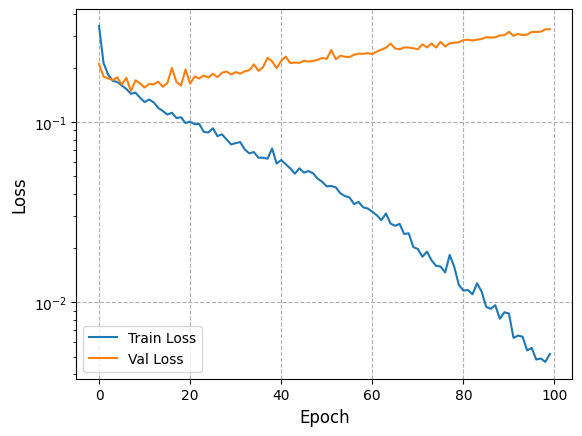

Accuracy: 95.00%
Precision (Macro): 0.63
Recall (Macro): 0.56
F1 (Macro): 0.5796
Average time per epoch: 43.7959s


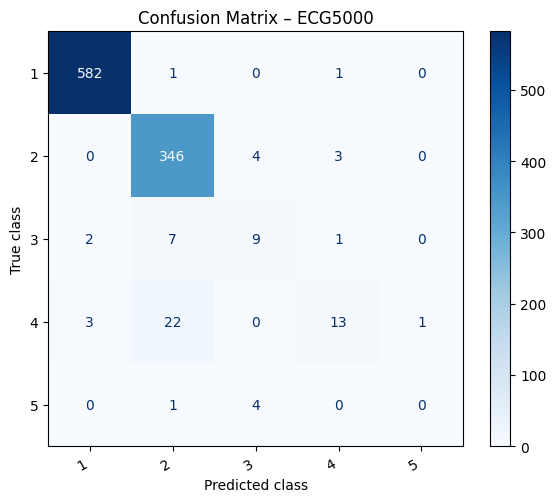

In [ ]:
"""sLSTM (and mLSTM / mixed xLSTM) models for ECG5000 time-series classification.

This script applies the xLSTM architecture to the ECG5000 univariate
time-series classification dataset. Each sample is a single-lead ECG
heartbeat waveform recorded over a fixed number of time steps, labeled as
one of 5 heartbeat classes (1 = Normal, 2-5 = various abnormal beat types).

Data layout (UCR-archive style .txt files):
    - Each row is one sample.
    - Column 0 is the integer class label.
    - Columns 1..N are the sequence values (a single channel).
    - Values are whitespace-separated (adjust `delimiter` in
      `load_ecg5000_txt` if your files are comma-separated instead).

Files used here:
    - Train/val pool: ECG5000_FOLD_1_800.txt
      (split into train/val with a STRATIFIED split so class proportions
      are preserved in both subsets.)
    - Held-out test set: ECG5000_FINAL_TEST_1000.txt

Three xLSTM variants are implemented and can be compared (sLSTM is run by
default below -- see `main()`):

    1) sLSTM (scalar LSTM) -- uses recurrent scalar-memory cells with
       exponential gating and explicit hidden-state recurrence. Does not
       use Q/K/V projections. Can use either the vanilla PyTorch backend
       or the optimized custom CUDA backend.

    2) mLSTM (matrix LSTM) -- uses matrix-valued associative memory with
       query, key, and value projections. The `qkv_proj_blocksize` controls
       the feature-group size used for the Q/K/V projections, while
       `conv1d_kernel_size` determines the local causal temporal context.

    3) xLSTM (mixed) -- combines mLSTM and sLSTM blocks within the same
       xLSTM block stack. In the implementation used here, the first block
       is an mLSTM block and the second block is an sLSTM block.

The same preprocessing, train/validation/test split, optimizer, loss
function, and evaluation metrics are used for all model variants so that
their classification performance and computational cost can be compared
directly.
"""


import time
from typing import Tuple

import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

from xlstm import (
    xLSTMBlockStack,
    xLSTMBlockStackConfig,
    mLSTMBlockConfig,
    mLSTMLayerConfig,
    sLSTMBlockConfig,
    sLSTMLayerConfig,
)

TRAIN_PATH = "dataProcessed/ECG5000_FOLD_2_TRAIN_3200.txt"
VAL_PATH = "dataProcessed/ECG5000_FOLD_2_VAL_800.txt"
TEST_PATH = "dataProcessed/ECG5000_FINAL_TEST_1000.txt"


class SLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int,
        n_classes: int,
        num_blocks: int,
        num_heads: int,
        context_length: int,
        conv1d_kernel_size: int,
    ):
        super().__init__()

        # Project input features to model dimension
        self.input_projection = nn.Linear(
            input_size,
            d_model,
        )

        # sLSTM configuration
        xlstm_config = xLSTMBlockStackConfig(
            slstm_block=sLSTMBlockConfig(
                slstm=sLSTMLayerConfig(
                    num_heads=num_heads,
                    conv1d_kernel_size=conv1d_kernel_size,  # Local causal temporal context
                    backend="vanilla",  # sLSTM implementation: vanilla PyTorch or custom CUDA
                ),
            ),
            context_length=context_length,  # Number of time steps
            num_blocks=num_blocks,  # Number of sLSTM blocks
            embedding_dim=d_model,
        )

        self.encoder = xLSTMBlockStack(xlstm_config)

        # Classification head
        self.output_projection = nn.Linear(
            d_model * context_length,
            n_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # (B, T, input_size) -> (B, T, d_model)
        x = self.input_projection(x)

        # (B, T, d_model)
        z = self.encoder(x)

        z_flat = z.flatten(start_dim=1)  # (bs, n_timesteps*d_model)

        output = self.output_projection(z_flat)  # (bs, n_classes)

        return output


class MLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int,
        n_classes: int,
        num_blocks: int,
        num_heads: int,
        context_length: int,
        conv1d_kernel_size: int,
        qkv_proj_blocksize: int,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model,
        )

        xlstm_config = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=conv1d_kernel_size,  # Local causal temporal context
                    qkv_proj_blocksize=qkv_proj_blocksize,  # Feature-group size for Q/K/V projections
                    num_heads=num_heads,
                )
            ),
            context_length=context_length,  # Number of time steps
            num_blocks=num_blocks,  # Number of mLSTM blocks
            embedding_dim=d_model,
        )

        self.encoder = xLSTMBlockStack(xlstm_config)

        # Classification head
        self.output_projection = nn.Linear(
            d_model * context_length,
            n_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        x = self.input_projection(x)  # (B, T, input_size)

        z = self.encoder(x)  # (B, T, d_model)

        z_flat = z.flatten(start_dim=1)  # (bs, n_timesteps*d_model)

        output = self.output_projection(z_flat)  # (bs, n_classes)
        return output


class XLSTMClassifier(nn.Module):
    def __init__(
        self,
        input_size: int,
        d_model: int,
        n_classes: int,
        num_blocks: int,
        num_heads: int,
        context_length: int,
        conv1d_kernel_size: int,
        qkv_proj_blocksize: int,
    ):
        super().__init__()

        self.input_projection = nn.Linear(
            input_size,
            d_model,
        )

        xlstm_config = xLSTMBlockStackConfig(
            mlstm_block=mLSTMBlockConfig(
                mlstm=mLSTMLayerConfig(
                    conv1d_kernel_size=conv1d_kernel_size,  # Local causal temporal context
                    qkv_proj_blocksize=qkv_proj_blocksize,  # Feature-group size for Q/K/V projections
                    num_heads=num_heads,
                )
            ),
            slstm_block=sLSTMBlockConfig(
                slstm=sLSTMLayerConfig(
                    num_heads=num_heads,
                    conv1d_kernel_size=conv1d_kernel_size,  # Local causal temporal context
                    backend="vanilla",  # sLSTM implementation: vanilla PyTorch or custom CUDA
                ),
            ),
            context_length=context_length,  # Number of time steps
            num_blocks=num_blocks,  # One mLSTM block + one sLSTM block
            embedding_dim=d_model,
            slstm_at=[1],  # Block 0: mLSTM, Block 1: sLSTM
        )

        self.encoder = xLSTMBlockStack(xlstm_config)

        # Classification head
        self.output_projection = nn.Linear(
            d_model * context_length,
            n_classes,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        # (B, T, input_size) -> (B, T, d_model)
        x = self.input_projection(x)

        # mLSTM -> sLSTM
        z = self.encoder(x)  # (B, T, d_model)

        z_flat = z.flatten(start_dim=1)  # (bs, n_timesteps*d_model)

        output = self.output_projection(z_flat)  # (B, n_classes)

        return output


def plot_confusion_matrix(
    true_indices: np.ndarray, predicted_indices: np.ndarray, class_names: list
) -> None:
    cm = confusion_matrix(
        true_indices,
        predicted_indices,
    )

    display = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )

    fig, ax = plt.subplots(figsize=(6, 5))

    display.plot(
        ax=ax,
        cmap="Blues",
        values_format="d",
    )

    plt.xticks(rotation=30, ha="right")
    plt.xlabel("Predicted class")
    plt.ylabel("True class")
    plt.title("Confusion Matrix – ECG5000")
    plt.tight_layout()
    plt.show()


def load_ecg5000_txt(file_path: str, delimiter=None) -> Tuple[np.ndarray, np.ndarray]:
    """Load an ECG5000 UCR-format .txt file.

    Expected layout: each row is one sample, column 0 is the integer class
    label, and the remaining columns are the (univariate) time-series
    values. `delimiter=None` lets numpy split on any whitespace; set to
    "," if your files are comma-separated.

    Args:
        file_path: Path to the ECG5000 .txt file.
        delimiter: Column delimiter (None = whitespace).

    Returns:
        x (np.ndarray): Array of shape (n_examples, n_timesteps, 1).
        y (np.ndarray): Labels of shape (n_examples,), as strings.
    """

    raw = np.loadtxt(file_path, delimiter=delimiter)

    y = raw[:, 0].astype(np.int64).astype(str)
    x = raw[:, 1:].astype(np.float32)

    # Add a trailing channel dimension: (n_examples, n_timesteps, 1)
    x = x[..., np.newaxis]

    return x, y


def plot_sample(data: np.ndarray, labels: np.ndarray, sample_idx: int) -> None:
    """Plot a single ECG sample.

    Args:
        data (np.ndarray): Array of shape (n_examples, n_timesteps, 1).
        labels (np.ndarray): Array of shape (n_examples,).
        sample_idx (int): Index of the sample to plot.
    """
    sample = data[sample_idx, :, 0]
    label = labels[sample_idx]

    time = np.arange(sample.shape[0])

    plt.figure(figsize=(8, 3))
    plt.plot(time, sample, linewidth=1.5)
    plt.title(f"ECG5000 sample — Class: {label}", fontsize=12)
    plt.xlabel("Time step")
    plt.ylabel("Amplitude")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


class ECG5000Dataset(Dataset):
    def __init__(self, data: np.ndarray, labels: np.ndarray):
        self.data = torch.tensor(data)
        self.labels = torch.tensor(labels)

    def __len__(self):
        return self.data.shape[0]

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]


def main():
    print(torch.cuda.is_available())  # Checks if Nvidia GPU is available
    print("Cuda version:", torch.version.cuda)  # Checks which cuda version is installed
    torch.manual_seed(42)

    ### Load the predefined stratified fold
    train_data, train_labels = load_ecg5000_txt(TRAIN_PATH)
    val_data, val_labels = load_ecg5000_txt(VAL_PATH)
    test_data, test_labels = load_ecg5000_txt(TEST_PATH)

    plot_sample(train_data, train_labels, sample_idx=0)

    unique_labels = np.unique(train_labels)

    print("Train shape:", train_data.shape)
    print("Val shape:", val_data.shape)
    print("Test shape:", test_data.shape)
    print("Classes:", unique_labels)

    ### One-hot encode labels
    ohe = OneHotEncoder()

    train_labels_ohe = ohe.fit_transform(
        train_labels.reshape(-1, 1)
    ).toarray()

    val_labels_ohe = ohe.transform(
        val_labels.reshape(-1, 1)
    ).toarray()

    test_labels_ohe = ohe.transform(
        test_labels.reshape(-1, 1)
    ).toarray()

    ### Scaling of the signals
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(
        train_data.reshape(-1, train_data.shape[-1])
    ).reshape(train_data.shape[0], train_data.shape[1], train_data.shape[-1])
    val_scaled = scaler.transform(val_data.reshape(-1, val_data.shape[-1])).reshape(
        val_data.shape[0], val_data.shape[1], val_data.shape[-1]
    )
    test_scaled = scaler.transform(test_data.reshape(-1, test_data.shape[-1])).reshape(
        test_data.shape[0], test_data.shape[1], test_data.shape[-1]
    )

    ### Initialize the datasets
    train_dataset = ECG5000Dataset(data=train_scaled, labels=train_labels_ohe)
    val_dataset = ECG5000Dataset(data=val_scaled, labels=val_labels_ohe)
    test_dataset = ECG5000Dataset(data=test_scaled, labels=test_labels_ohe)

    bs = 32
    lr = 0.0001
    train_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=bs, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)

    ### Initialize model and optimizer
    input_size = train_data.shape[-1]  # 1 (univariate ECG signal)
    n_classes = train_labels_ohe.shape[1]  # 5 for ECG5000
    d_model = 64
    num_blocks = 1  # set to 2 or more for xLSTM with mLSTM and sLSTM block
    num_heads = 4
    conv1d_kernel_size = 4
    n_timesteps = train_data.shape[1]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = SLSTMClassifier(
        input_size=input_size,
        n_classes=n_classes,
        d_model=d_model,
        num_blocks=num_blocks,
        num_heads=num_heads,
        context_length=n_timesteps,
        conv1d_kernel_size=conv1d_kernel_size,
    ).to(device)

    ### Print number of trainable parameters
    num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Model has {num_params} trainable parameters.")

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    criterion = nn.CrossEntropyLoss()

    epochs = 100

    train_losses = []
    val_losses = []
    best_val_loss = float("inf")
    best_val_epoch = 0
    time_per_epoch = []

    for epoch in range(epochs):
        start_time = time.time()  # Start time per epoch

        model.train()
        train_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(x_batch)

            loss = criterion(
                predictions,
                y_batch,
            )

            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)
                predictions = model(x_batch)

                loss = criterion(
                    predictions,
                    y_batch,
                )

                val_loss += loss.item()

            val_loss /= len(val_loader)
            val_losses.append(val_loss)

        end_time = time.time()
        time_per_epoch.append(end_time - start_time)  # Appends the time per epoch

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_epoch = epoch
            torch.save(model.state_dict(), "best_model_slstm.pth")

        print(
            f"Epoch: {epoch + 1:3d} | "
            f"Train loss: {train_loss:.8f}"
            f"| Val loss: {val_loss:.8f}"
            f" | "
            f"Best Val loss: {best_val_loss:.8f}"
            f" | "
            f"Best Val epoch: {best_val_epoch + 1}"
        )

    ### Plot the loss function
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.ylabel("Loss", fontsize=12)
    plt.xlabel("Epoch", fontsize=12)
    plt.yscale("log")
    plt.grid(linestyle="dashed")
    plt.legend()
    plt.show()

    ### Model Testing
    best_model = SLSTMClassifier(
        input_size=input_size,
        n_classes=n_classes,
        d_model=d_model,
        num_blocks=num_blocks,
        num_heads=num_heads,
        context_length=n_timesteps,
        conv1d_kernel_size=conv1d_kernel_size,
    ).to(device)

    best_model.load_state_dict(torch.load("best_model_slstm.pth"))

    best_model.eval()
    all_logits = []
    all_targets = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(device)

            logits = best_model(x_batch)

            all_logits.append(logits.cpu())
            all_targets.append(y_batch.cpu())

    all_logits = torch.cat(all_logits, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    predicted_indices = all_logits.argmax(dim=1).numpy()
    true_indices = all_targets.argmax(dim=1).numpy()

    ### Metrics
    accuracy = accuracy_score(
        true_indices,
        predicted_indices,
    )

    balanced_accuracy = balanced_accuracy_score(
    true_indices,
    predicted_indices,
    )

    precision = precision_score(true_indices, predicted_indices, average="macro")
    recall = recall_score(true_indices, predicted_indices, average="macro")
    f1_macro = f1_score(true_indices, predicted_indices, average="macro")

    print(f"Accuracy: {accuracy*100:.2f}%")
    print(f"Balanced Accuracy: {balanced_accuracy*100:.2f}%")
    print(f"Precision (Macro): {precision:.2f}")
    print(f"Recall (Macro): {recall:.2f}")
    print(f"F1 (Macro): {f1_macro:.4f}")

    average_time_per_epoch = sum(time_per_epoch) / len(time_per_epoch)
    print(f"Average time per epoch: {average_time_per_epoch:.4f}s")

    ### Confusion Matrix
    # ohe.categories_[0] gives back the original string labels in sorted
    # order matching the one-hot column order used for arg max above.
    class_names = list(ohe.categories_[0])
    plot_confusion_matrix(true_indices, predicted_indices, class_names)


if __name__ == "__main__":
    main()

In [8]:
import torch

print(torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
Tesla T4
